In [1]:
import pandas as pd

df = pd.read_csv(
    r"D:\Retail Pulse Project\data\cleaned_retail.csv"
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

C:\Users\PAVILION\AppData\Local\Temp\ipykernel_33636\64770208.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [2]:
snapshot_date = (
    df["InvoiceDate"].max()
)

rfm = (
    df.groupby("Customer ID")
    .agg({
        "InvoiceDate": lambda x:
        (
            snapshot_date
            - x.max()
        ).days,

        "Invoice": "nunique",

        "Revenue": "sum"
    })
)

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,77556.46
12347.0,1,8,5633.32
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm
)

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = (
    kmeans.fit_predict(
        rfm_scaled
    )
)

In [5]:
rfm["Cluster"].value_counts()

Cluster
1    3575
0    1924
3     354
4      24
2       4
Name: count, dtype: int64

In [6]:
segment_map = {
    0:"VIP Customers",
    1:"Loyal Customers",
    2:"Regular Customers",
    3:"At Risk",
    4:"Lost Customers"
}

rfm["Segment"] = (
    rfm["Cluster"]
    .map(segment_map)
)

<Axes: ylabel='count'>

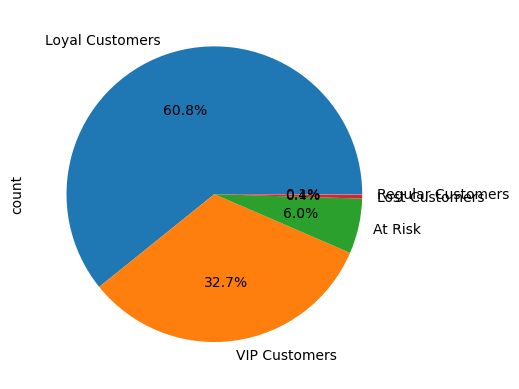

In [10]:
rfm["Segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

In [9]:
rfm.to_csv(
    r"D:\Retail Pulse Project\data\customer_segments.csv"
)
print("Successfully Created!!")


Successfully Created!!
